In [1]:
from pathlib import Path

from intrarepresentational_alignment.data import load_metanet

c:\Users\Student\Documents\Repositories\intrarepresentational-alignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = Path("data/mr-en-20250924142102.rdf")

In [3]:
repo = load_metanet(DATA_PATH)
print(f"Loaded  {len(repo.metaphors):,} metaphors, {len(repo.frames):,} frames, "
      f"{len(repo.mappings):,} mappings, {len(repo.examples):,} examples")

http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest French frame does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest Spanish frame does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Metaphor_Experiential basis does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Related metaphor_Description does not look like a valid URI, trying to serialize this will break.


Loaded  875 metaphors, 951 frames, 645 mappings, 5,616 examples


## LCC Metaphor Corpus - Source & Target Domain Kernel Matrices

In [4]:
from pathlib import Path
from collections import Counter
from intrarepresentational_alignment.data import load_lcc
from intrarepresentational_alignment.analysis import group_domain_pairs

LCC_PATH = Path("data/en_small.xml")
instances = load_lcc(LCC_PATH)
print(f"Loaded {len(instances):,} LCC instances")

all_domain_pairs = group_domain_pairs(instances)
print(f"With explicit source concept (excl. OTHER): {sum(len(v) for v in all_domain_pairs.values()):,} expression pairs")

print(f"\nTop 15 (source domain -> target domain) pairs:")
pair_counts = Counter({k: len(v) for k, v in all_domain_pairs.items()})
for (src, tgt), n in pair_counts.most_common(15):
    print(f"  {src:<30} -> {tgt:<25} (n={n})")

Loaded 16,265 LCC instances
With explicit source concept (excl. OTHER): 3,336 expression pairs

Top 15 (source domain -> target domain) pairs:
  DISEASE                        -> POVERTY                   (n=43)
  PROTECTION                     -> GUN_RIGHTS                (n=34)
  ABYSS                          -> POVERTY                   (n=22)
  PHYSICAL_LOCATION              -> POVERTY                   (n=22)
  PROTECTION                     -> GUNS                      (n=19)
  STRUGGLE                       -> POVERTY                   (n=18)
  PROTECTION                     -> DEMOCRACY                 (n=18)
  MOVEMENT                       -> CONTROL_OF_GUNS           (n=18)
  PHYSICAL_BURDEN                -> TAXATION                  (n=17)
  MOVEMENT                       -> GOVERNMENT                (n=17)
  MOVEMENT                       -> GUNS                      (n=16)
  ANIMAL                         -> GUNS                      (n=15)
  MOVEMENT                   

## Per-domain CKA experiments

In [5]:
import numpy as np
from intrarepresentational_alignment.embedding import Embedder
from intrarepresentational_alignment.models import EmbeddingModel
from intrarepresentational_alignment.analysis import analyse_domain_pairs

MIN_PAIRS = 8
MAX_PAIRS = 30
N_PERMS   = 500

embedder      = Embedder(EmbeddingModel.ALL_MINILM_L6_V2)
selected_pairs = {k: v for k, v in all_domain_pairs.items() if MIN_PAIRS <= len(v) <= MAX_PAIRS}
selected       = sorted(selected_pairs, key=lambda k: len(selected_pairs[k]), reverse=True)
domain_n       = {k: len(v) for k, v in selected_pairs.items()}

print(f'Domains with {MIN_PAIRS}-{MAX_PAIRS} pairs: {len(selected)}')

rng            = np.random.default_rng(42)
domain_results = analyse_domain_pairs(selected_pairs, embedder, n_permutations=N_PERMS, rng=rng)

print(f"{'Source domain':<28} {'Target domain':<22} {'n':>4}  {'CKA':>6}  {'p':>6}")
print("-" * 70)
for key in selected:
    r = domain_results[key]
    src_concept, tgt_concept = key
    sig = " *" if r.cka.p_value < 0.05 else ""
    print(f"{src_concept:<28} {tgt_concept:<22} {domain_n[key]:>4}  "
          f"{r.cka.observed:>6.3f}  {r.cka.p_value:>6.3f}{sig}")

Domains with 8-30 pairs: 75
Source domain                Target domain             n     CKA       p
----------------------------------------------------------------------
ABYSS                        POVERTY                  22   0.311   0.010 *
PHYSICAL_LOCATION            POVERTY                  22   0.342   0.004 *
PROTECTION                   GUNS                     19   0.358   0.012 *
STRUGGLE                     POVERTY                  18   0.262   0.924
PROTECTION                   DEMOCRACY                18   0.386   0.034 *
MOVEMENT                     CONTROL_OF_GUNS          18   0.253   0.226
PHYSICAL_BURDEN              TAXATION                 17   0.139   0.590
MOVEMENT                     GOVERNMENT               17   0.460   0.078
MOVEMENT                     GUNS                     16   0.278   0.968
ANIMAL                       GUNS                     15   0.473   0.740
MOVEMENT                     DEMOCRACY                14   0.400   0.234
BUILDING         

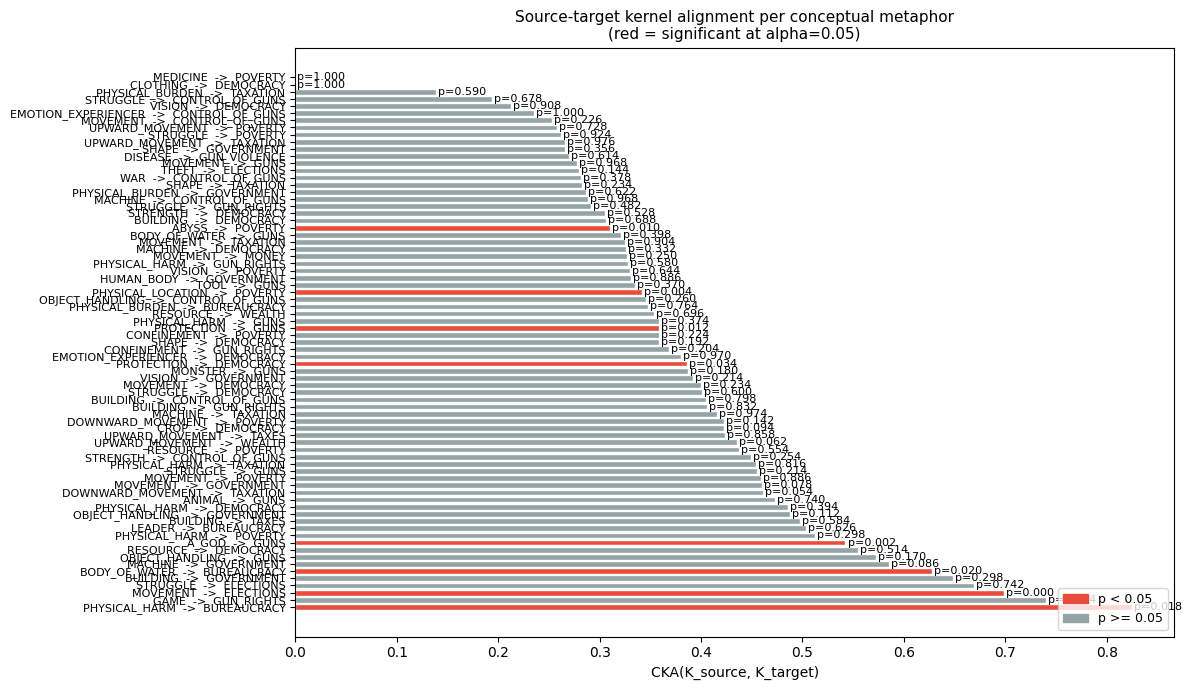

In [6]:
from intrarepresentational_alignment.viz import plot_cka_bar
plot_cka_bar(domain_results)

### Graph Edit Distance alignment

In [7]:
from intrarepresentational_alignment.viz import print_alignment_table
print_alignment_table(domain_results, selected)

Source domain                Target domain             CKA     GED      WL     MCS   p(CKA)   p(GED)   p(WL)   p(MCS)
--------------------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                 0.311   0.428   0.411   0.428   0.010*   0.960   0.834    0.956 
PHYSICAL_LOCATION            POVERTY                 0.342   0.198   0.180   0.198   0.004*   1.000   1.000    1.000 
PROTECTION                   GUNS                    0.358   0.249   0.229   0.249   0.012*   0.008*  0.490    0.006*
STRUGGLE                     POVERTY                 0.262   0.354   0.247   0.354   0.924    0.992   0.302    0.988 
PROTECTION                   DEMOCRACY               0.386   0.301   0.075   0.301   0.034*   0.976   0.086    0.968 
MOVEMENT                     CONTROL_OF_GUNS         0.253   0.326   0.286   0.326   0.226    0.240   0.694    0.208 
PHYSICAL_BURDEN              TAXATION                0.139   0.

In [8]:
from intrarepresentational_alignment.viz import print_summary_table
print_summary_table(domain_results, selected)

Source domain           Target domain              n     CKA   p(CKA)     GED   p(GED)      WL   p(WL)     MCS   p(MCS)
-----------------------------------------------------------------------------------------------------------------------
PHYSICAL_HARM           BUREAUCRACY                8   0.825   0.018*   0.194   0.024*   0.091  0.926    0.194   0.020*
MOVEMENT                ELECTIONS                  9   0.699   0.000*   0.419   0.022*   0.418  0.848    0.419   0.002*
BODY_OF_WATER           BUREAUCRACY                9   0.627   0.020*   0.294   0.098    0.273  0.990    0.294   0.104 
OBJECT_HANDLING         GUNS                       8   0.572   0.170    0.260   0.018*   0.256  1.000    0.260   0.016*
A_GOD                   GUNS                      11   0.542   0.002*   0.376   0.040*   0.376  0.902    0.376   0.034*
DOWNWARD_MOVEMENT       TAXATION                  13   0.461   0.054    0.291   0.076    0.281  0.388    0.291   0.048*
MOVEMENT                GOVERNMENT      

### WL and MCS graph-distance alignment

In [9]:
from intrarepresentational_alignment.viz import print_graph_distances_table
print_graph_distances_table(domain_results, selected)

Source domain                Target domain             CKA     GED      WL     MCS   p(CKA)   p(GED)   p(WL)   p(MCS)
------------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                 0.311   0.428   0.411   0.428   0.010*   0.960   0.834    0.956 
PHYSICAL_LOCATION            POVERTY                 0.342   0.198   0.180   0.198   0.004*   1.000   1.000    1.000 
PROTECTION                   GUNS                    0.358   0.249   0.229   0.249   0.012*   0.008*  0.490    0.006*
STRUGGLE                     POVERTY                 0.262   0.354   0.247   0.354   0.924    0.992   0.302    0.988 
PROTECTION                   DEMOCRACY               0.386   0.301   0.075   0.301   0.034*   0.976   0.086    0.968 
MOVEMENT                     CONTROL_OF_GUNS         0.253   0.326   0.286   0.326   0.226    0.240   0.694    0.208 
PHYSICAL_BURDEN              TAXATION                0.139   0.226   0.

In [10]:
# Summary: pairs significant under any of the four metrics
from intrarepresentational_alignment.viz import print_summary_table
print_summary_table(domain_results, selected)

Source domain           Target domain              n     CKA   p(CKA)     GED   p(GED)      WL   p(WL)     MCS   p(MCS)
-----------------------------------------------------------------------------------------------------------------------
PHYSICAL_HARM           BUREAUCRACY                8   0.825   0.018*   0.194   0.024*   0.091  0.926    0.194   0.020*
MOVEMENT                ELECTIONS                  9   0.699   0.000*   0.419   0.022*   0.418  0.848    0.419   0.002*
BODY_OF_WATER           BUREAUCRACY                9   0.627   0.020*   0.294   0.098    0.273  0.990    0.294   0.104 
OBJECT_HANDLING         GUNS                       8   0.572   0.170    0.260   0.018*   0.256  1.000    0.260   0.016*
A_GOD                   GUNS                      11   0.542   0.002*   0.376   0.040*   0.376  0.902    0.376   0.034*
DOWNWARD_MOVEMENT       TAXATION                  13   0.461   0.054    0.291   0.076    0.281  0.388    0.291   0.048*
MOVEMENT                GOVERNMENT      

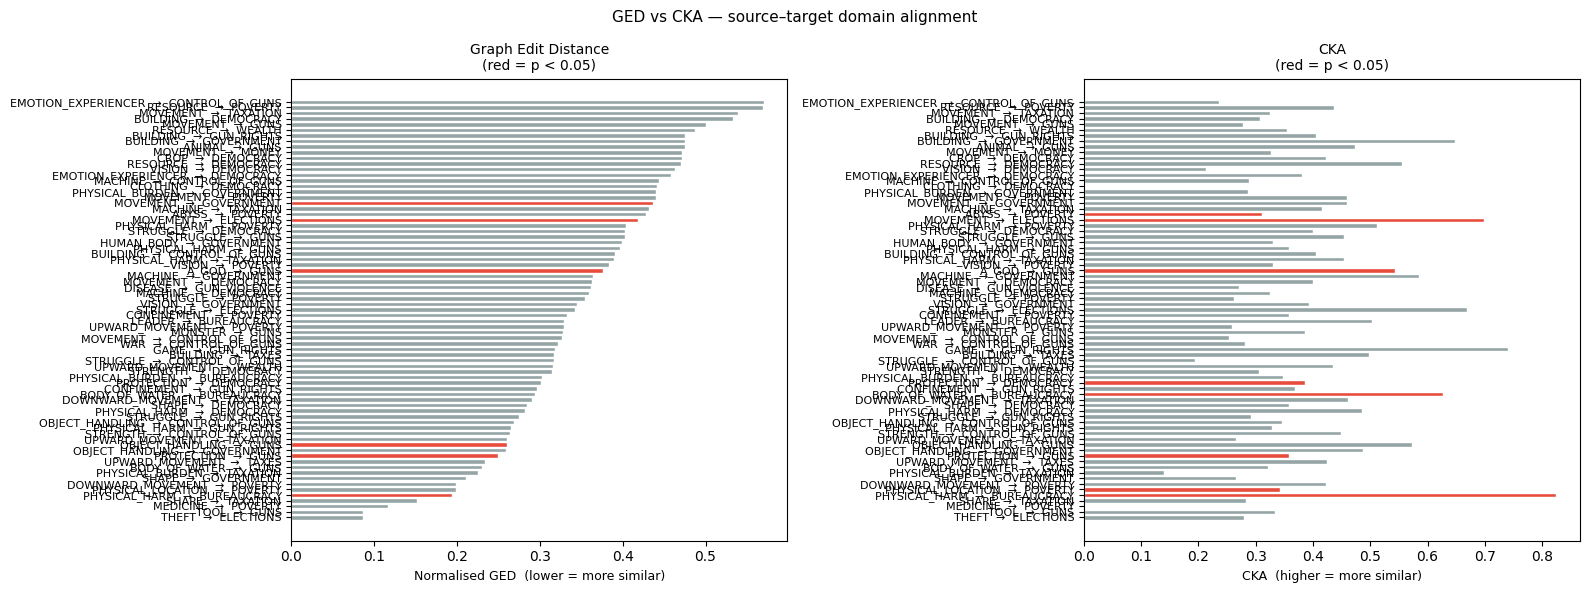

In [11]:
from intrarepresentational_alignment.viz import plot_ged_vs_cka
plot_ged_vs_cka(domain_results)

### Sparse kernel (TopFraction 20%) — re-run experiments

In [12]:
import numpy as np
from intrarepresentational_alignment.similarity import CosineSimilarity, SparseKernel
from intrarepresentational_alignment.graph import TopFraction
from intrarepresentational_alignment.analysis import analyse_domain_pairs

EDGE_FRACTION = 0.20
sparse_metric = SparseKernel(CosineSimilarity(), TopFraction(EDGE_FRACTION))

rng            = np.random.default_rng(42)
sparse_results = analyse_domain_pairs(
    selected_pairs, embedder, metric=sparse_metric, n_permutations=N_PERMS, rng=rng
)

print(f"{'Source domain':<28} {'Target domain':<22} {'CKA(dense)':>10}  {'CKA(sparse)':>11}  {'p(dense)':>8}  {'p(sparse)':>9}")
print("-" * 96)
for key in selected:
    src_concept, tgt_concept = key
    dense    = domain_results[key]
    sparse_r = sparse_results[key]
    sig_d = " *" if dense.cka.p_value    < 0.05 else "  "
    sig_s = " *" if sparse_r.cka.p_value < 0.05 else "  "
    print(f"{src_concept:<28} {tgt_concept:<22} "
          f"{dense.cka.observed:>10.3f}  {sparse_r.cka.observed:>11.3f}  "
          f"{dense.cka.p_value:>8.3f}{sig_d}  {sparse_r.cka.p_value:>9.3f}{sig_s}")

Source domain                Target domain          CKA(dense)  CKA(sparse)  p(dense)  p(sparse)
------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                     0.311        0.156     0.010 *      0.030 *
PHYSICAL_LOCATION            POVERTY                     0.342        0.022     0.004 *      0.426  
PROTECTION                   GUNS                        0.358        0.125     0.012 *      0.080  
STRUGGLE                     POVERTY                     0.262        0.110     0.924        0.150  
PROTECTION                   DEMOCRACY                   0.386        0.031     0.034 *      0.410  
MOVEMENT                     CONTROL_OF_GUNS             0.253        0.035     0.226        0.426  
PHYSICAL_BURDEN              TAXATION                    0.139        0.130     0.590        0.108  
MOVEMENT                     GOVERNMENT                  0.460       -0.046     0.078        0.808 

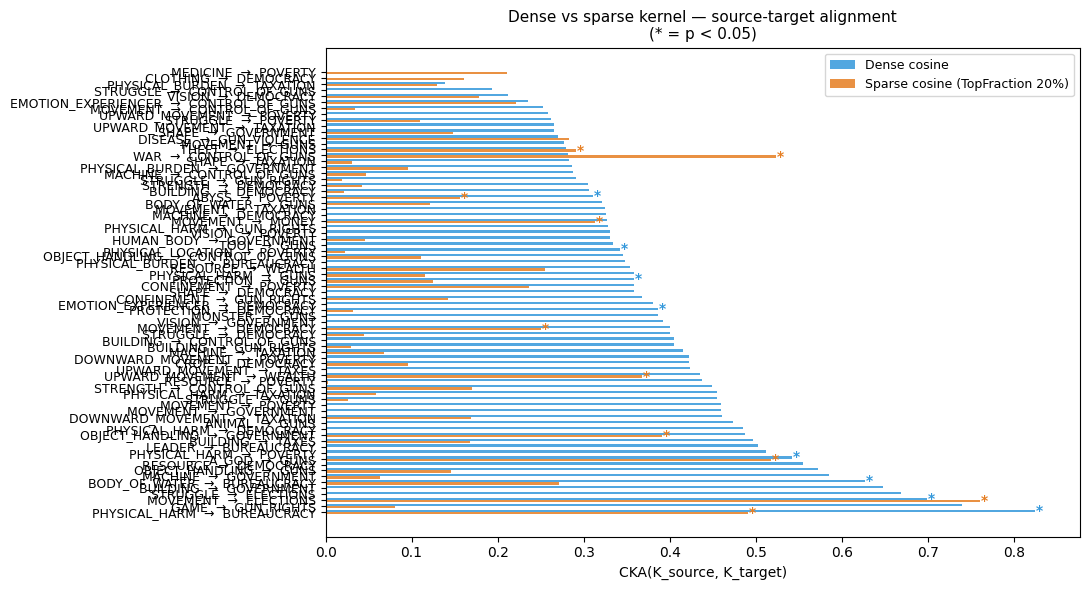

In [13]:
from intrarepresentational_alignment.viz import plot_dense_vs_sparse
plot_dense_vs_sparse(domain_results, sparse_results, EDGE_FRACTION)